In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import glob, os
from cartopy import crs as ccrs, feature as cfeature
from cartopy.util import add_cyclic_point
from matplotlib.colors import CenteredNorm
import dask

In [2]:
ns_per_dec = 10*365*24*60*60*1e9

In [3]:
def deseasonalize(da):
    gb = da.groupby('time.month')
    anom = gb - gb.mean(dim='time')
    return anom

In [4]:
ersst = xr.open_dataset('/roselab_rit/rford/research/sst.mnmean.nc').sst

In [5]:
ersst

<xarray.DataArray 'sst' (time: 2065, lat: 89, lon: 180)> Size: 132MB
[33081300 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-01-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

In [6]:
era5_slp = xr.open_mfdataset('/roselab_rit/rford/ERA5/*msl*')

In [7]:
era5_slp

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 528, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2022-12-01
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    MSL        (time, latitude, longitude) float32 2GB dask.array<chunksize=(3, 389, 776), meta=np.ndarray>
    utc_date   (time) int32 2kB dask.array<chunksize=(12,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB 1 data to netC...
    NETCDF_VERSION:       4.6.1
    CONVERSION_PLATFORM:  Linux casper02 3.10.0-693.21.1.el7.x86_64 #1 SMP We...
    CONVERSION_DATE:      Mon Nov 11 07:47:57 MST 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Mon Nov 11 07:47:58 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

In [8]:
lr_mesaclip_dir = '/roselab_rit/rford/MESACLIP-regridded/CESM_LR/'
lr_dir_list = sorted(glob.glob(lr_mesaclip_dir+'*'))

Run this twice to remove error:

In [9]:
def get_slp_vars(ds):
    return ds.get(['lat', 'lon', 'psl'])

lr_ds_list_slp = []
for lr_dir in lr_dir_list:
    lr_ds_list_slp.append(xr.open_mfdataset(lr_dir+'/atm/*psl*.nc', preprocess=get_slp_vars))

In [10]:
def get_sst_vars(ds):
    return ds.get(['lat', 'lon', 'tos'])

lr_ds_list_sst = []
for lr_dir in lr_dir_list:
    lr_ds_list_sst.append(xr.open_mfdataset(lr_dir+'/ocn/proc/month_1/*tos*.nc', preprocess=get_sst_vars, data_vars='all'))

In [11]:
lr_slp_ds = xr.concat(lr_ds_list_slp, dim='ens_member', join='inner')

In [12]:
lr_sst_ds = xr.concat(lr_ds_list_sst, dim='ens_member', join='inner')

In [13]:
lr_slp_ds

<xarray.Dataset> Size: 6GB
Dimensions:  (ens_member: 22, time: 1032, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 8kB 1920-02-01 00:00:00 ... 2006-01-01 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: ens_member
Data variables:
    psl      (ens_member, time, lat, lon) float32 6GB dask.array<chunksize=(1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/21)
    CDI:              Climate Data Interface version 2.5.2 (https://mpimet.mp...
    Conventions:      CF-1.0
    source:           CAM
    np:               4
    ne:               30
    case:             B.E.13.BHISTC5.ne30g16.sehires38.003.sunway
    ...               ...
    remap_version:    5.3.4
    map_file:         map_ne30np4_TO_1x1_aave.260501.nc
    input_file:       /glade/campaign/collections/cmip/CMIP6/CESM-HR/RDA/lowr...
    CDO:              Climate Data Operators version 2.5.2 (https://mpimet.mp...
    history:          Sat May  2 14:02:04 2026: ncrename -O -v PSL,psl cam_tm...
    NCO:              netCDF Operators version 5.3.4 (Homepage = http://nco.s...

In [14]:
lr_sst_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (ens_member: 22, time: 2171, nlat: 180, nlon: 360, z_t: 1)
Coordinates:
  * time     (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
  * z_t      (z_t) float32 4B 500.0
Dimensions without coordinates: ens_member, nlat, nlon
Data variables:
    lat      (ens_member, time, nlat) float64 69MB dask.array<chunksize=(1, 1086, 180), meta=np.ndarray>
    lon      (ens_member, time, nlon) float64 138MB dask.array<chunksize=(1, 1086, 360), meta=np.ndarray>
    tos      (ens_member, time, z_t, nlat, nlon) float32 12GB dask.array<chunksize=(1, 1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/17)
    title:           B.E.13.BHISTC5.ne30g16.sehires38.003.sunway
    Conventions:     CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netcdf/CF-curr...
    contents:        Diagnostic and Prognostic Variables
    source:          CCSM POP2, the CCSM Ocean Component
    revision:        $Id: tavg.F90 56176 2013-12-20 18:35:46Z mlevy@ucar.edu $
    calendar:        All years have exactly  365 days.
    ...              ...
    history:         Tue Apr 21 02:07:04 2026: ncrcat -O /glade/derecho/scrat...
    remap_script:    ncremap
    remap_hostname:  crhtc92
    remap_version:   5.3.4
    map_file:        map_gx1v6_TO_1x1d_blin.230528.nc
    input_file:      /glade/work/scsan/regrid/regrid_cesmlr/Pedro/pop_temp2.nc

In [15]:
lr_slp_e11 = xr.open_dataset('/roselab_rit/rford/MESACLIP-regridded/b.e13.BHISTC5.ne30_g16.cesm-ihesp-hires1.0.46-1920-2005.011.cam.h0.psl.192001-200512.nc')

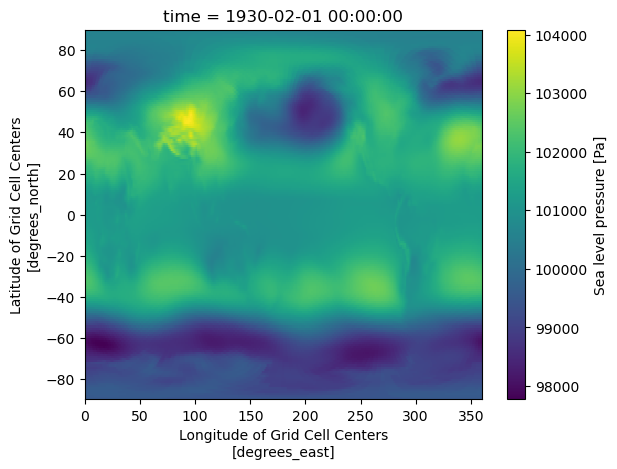

In [16]:
lr_slp_ds.psl.isel(time=120, ens_member=10).plot()

In [17]:
lr_sst_e11 = xr.open_dataset('/roselab_rit/rford/MESACLIP-regridded/CESM_LR/b.e13.HF-TNST.rcp85.ne30_g16.1920-2100.011/ocn/proc/month_1/b.e13.HF-TNST.rcp85.ne30_g16.1920-2100.011.pop.h.tos.192001-200512.nc')\
    .rename({'nlon': 'lon', 'nlat': 'lat'}).assign_coords({'lon': lr_slp_e11.lon, 'lat': lr_slp_e11.lat})

In [18]:
ersst_sep = ersst.sel(time=ersst.time.dt.month.isin(9)).sel(time=slice('1986', '2014'))

In [19]:
era5slp_sep = era5_slp.MSL.sel(time=era5_slp.time.dt.month.isin(9)).sel(time=slice('1986', '2014'))

In [20]:
lr_slp_sep = lr_slp_ds.psl.sel(time=lr_slp_ds.time.dt.month.isin(10)).sel(time=slice('1940', '1968'))
lr_sst_sep = lr_sst_ds.tos.sel(time=lr_sst_ds.time.dt.month.isin(10)).sel(time=slice('1940', '1968'))

In [21]:
lr_slp_sep

<xarray.DataArray 'psl' (ens_member: 22, time: 29, lat: 180, lon: 360)> Size: 165MB
dask.array<getitem, shape=(22, 29, 180, 360), dtype=float32, chunksize=(1, 1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 232B 1940-10-01 00:00:00 ... 1968-10-01 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: ens_member
Attributes:
    long_name:     Sea level pressure
    units:         Pa
    cell_methods:  time: mean

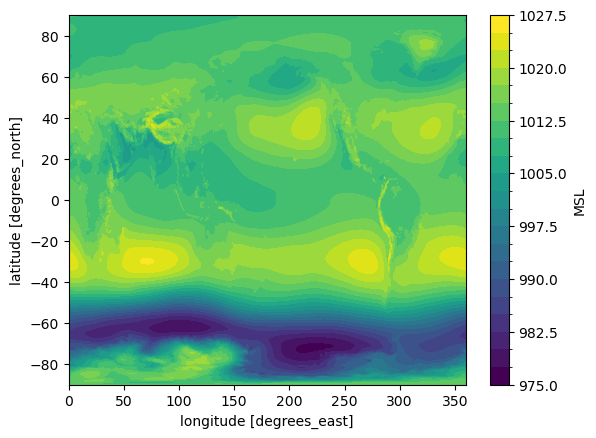

In [22]:
(0.01*era5slp_sep.mean(dim='time')).plot.contourf(levels=21)

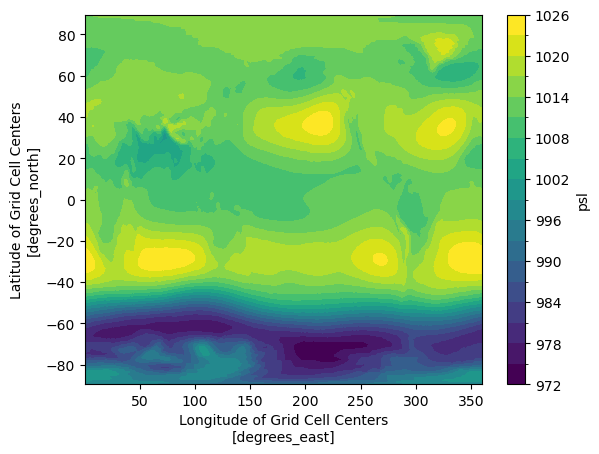

In [23]:
(0.01*lr_slp_sep.mean(dim='time').isel(ens_member=0)).plot.contourf(levels=21)

In [24]:
lr_slp_sep_mean = lr_slp_sep.isel(ens_member=10).mean(dim='time').compute()
era5slp_sep_mean = era5slp_sep.mean(dim='time').compute()

lr_asl_sep_mean = lr_slp_sep_mean.where(lr_slp_sep_mean==lr_slp_sep_mean.min(), drop=True).squeeze()
era5_asl_sep_mean = era5slp_sep_mean.where(era5slp_sep_mean==era5slp_sep_mean.min(), drop=True).squeeze()

In [25]:
lr_asl_sep_mean

<xarray.DataArray 'psl' ()> Size: 4B
array(97437.88, dtype=float32)
Coordinates:
    lat      float64 8B -72.5
    lon      float64 8B 207.5

In [26]:
ersst_anom = deseasonalize(ersst)

In [27]:
ersst_trend = ns_per_dec*((ersst_anom.sel(time=slice('1986', '2014'))).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).compute()

In [28]:
ersst_sep_trend = ns_per_dec*(ersst_sep.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).compute()

In [29]:
era5slp_anom = deseasonalize(era5_slp.MSL)

In [30]:
era5slp_trend = ns_per_dec*((era5slp_anom.sel(time=slice('1986', '2014'))).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).compute()

In [31]:
era5slp_sep_trend = ns_per_dec*(era5slp_sep.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).compute()

In [32]:
lr_slp_anom = deseasonalize(lr_slp_ds.psl).sel(time=slice('1940', '1968'))
lr_sst_anom = deseasonalize(lr_sst_ds.tos).sel(time=slice('1940', '1968'))

In [33]:
lr_slp_trend = ns_per_dec*(lr_slp_anom.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).squeeze().compute()

lr_slp_trend_e11fc = lr_slp_trend.isel(ens_member=10) - lr_slp_trend.mean(dim='ens_member')

In [34]:
lr_slp_sep_trend = ns_per_dec*(lr_slp_sep.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).squeeze().compute()

lr_slp_sep_trend_e11fc = lr_slp_sep_trend.isel(ens_member=10) - lr_slp_sep_trend.mean(dim='ens_member')

In [35]:
lr_sst_trend = ns_per_dec*(lr_sst_anom.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).squeeze().compute()

lr_sst_trend_e11fc = lr_sst_trend.isel(ens_member=10) - lr_sst_trend.mean(dim='ens_member')

In [36]:
lr_sst_sep_trend = ns_per_dec*(lr_sst_sep.polyfit('time', deg=1).sel(degree=1).polyfit_coefficients).squeeze().compute()

lr_sst_sep_trend_e11fc = lr_sst_sep_trend.isel(ens_member=10) - lr_sst_sep_trend.mean(dim='ens_member')

In [37]:
np.concatenate([np.arange(-.8, .1, 0.1), np.arange(0.1, .81, 0.1)])

array([-8.00000000e-01, -7.00000000e-01, -6.00000000e-01, -5.00000000e-01,
       -4.00000000e-01, -3.00000000e-01, -2.00000000e-01, -1.00000000e-01,
       -2.22044605e-16,  1.00000000e-01,  2.00000000e-01,  3.00000000e-01,
        4.00000000e-01,  5.00000000e-01,  6.00000000e-01,  7.00000000e-01,
        8.00000000e-01])

In [38]:
lr_sst_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (ens_member: 22, time: 2171, nlat: 180, nlon: 360, z_t: 1)
Coordinates:
  * time     (time) object 17kB 1920-02-01 00:00:00 ... 2101-01-01 00:00:00
  * z_t      (z_t) float32 4B 500.0
Dimensions without coordinates: ens_member, nlat, nlon
Data variables:
    lat      (ens_member, time, nlat) float64 69MB dask.array<chunksize=(1, 1086, 180), meta=np.ndarray>
    lon      (ens_member, time, nlon) float64 138MB dask.array<chunksize=(1, 1086, 360), meta=np.ndarray>
    tos      (ens_member, time, z_t, nlat, nlon) float32 12GB dask.array<chunksize=(1, 1, 1, 180, 360), meta=np.ndarray>
Attributes: (12/17)
    title:           B.E.13.BHISTC5.ne30g16.sehires38.003.sunway
    Conventions:     CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netcdf/CF-curr...
    contents:        Diagnostic and Prognostic Variables
    source:          CCSM POP2, the CCSM Ocean Component
    revision:        $Id: tavg.F90 56176 2013-12-20 18:35:46Z mlevy@ucar.edu $
    calendar:        All years have exactly  365 days.
    ...              ...
    history:         Tue Apr 21 02:07:04 2026: ncrcat -O /glade/derecho/scrat...
    remap_script:    ncremap
    remap_hostname:  crhtc92
    remap_version:   5.3.4
    map_file:        map_gx1v6_TO_1x1d_blin.230528.nc
    input_file:      /glade/work/scsan/regrid/regrid_cesmlr/Pedro/pop_temp2.nc

In [39]:
ersst_trend_cyc, ersst_lon_cyc = add_cyclic_point(ersst_trend, coord=ersst_trend.lon)
ersst_sep_trend_cyc = add_cyclic_point(ersst_sep_trend)

era5slp_trend_cyc, era_lon_cyc = add_cyclic_point(era5slp_trend, coord=era5slp_trend.longitude)
era5slp_sep_trend_cyc = add_cyclic_point(era5slp_sep_trend)

lr_sst_trend_cyc, lr_lon_cyc = add_cyclic_point(lr_sst_trend_e11fc, coord=lr_sst_ds.lon.isel(ens_member=0, time=0))
lr_sst_sep_trend_cyc = add_cyclic_point(lr_sst_sep_trend_e11fc)

lr_slp_trend_cyc = add_cyclic_point(lr_slp_trend_e11fc)
lr_slp_sep_trend_cyc = add_cyclic_point(lr_slp_sep_trend_e11fc)

In [40]:
lr_slp_mean_cyc = add_cyclic_point(lr_slp_sep_mean)

Text(0.5, 1.0, 'LR CESM1.3 EM11 (1940–1968)')

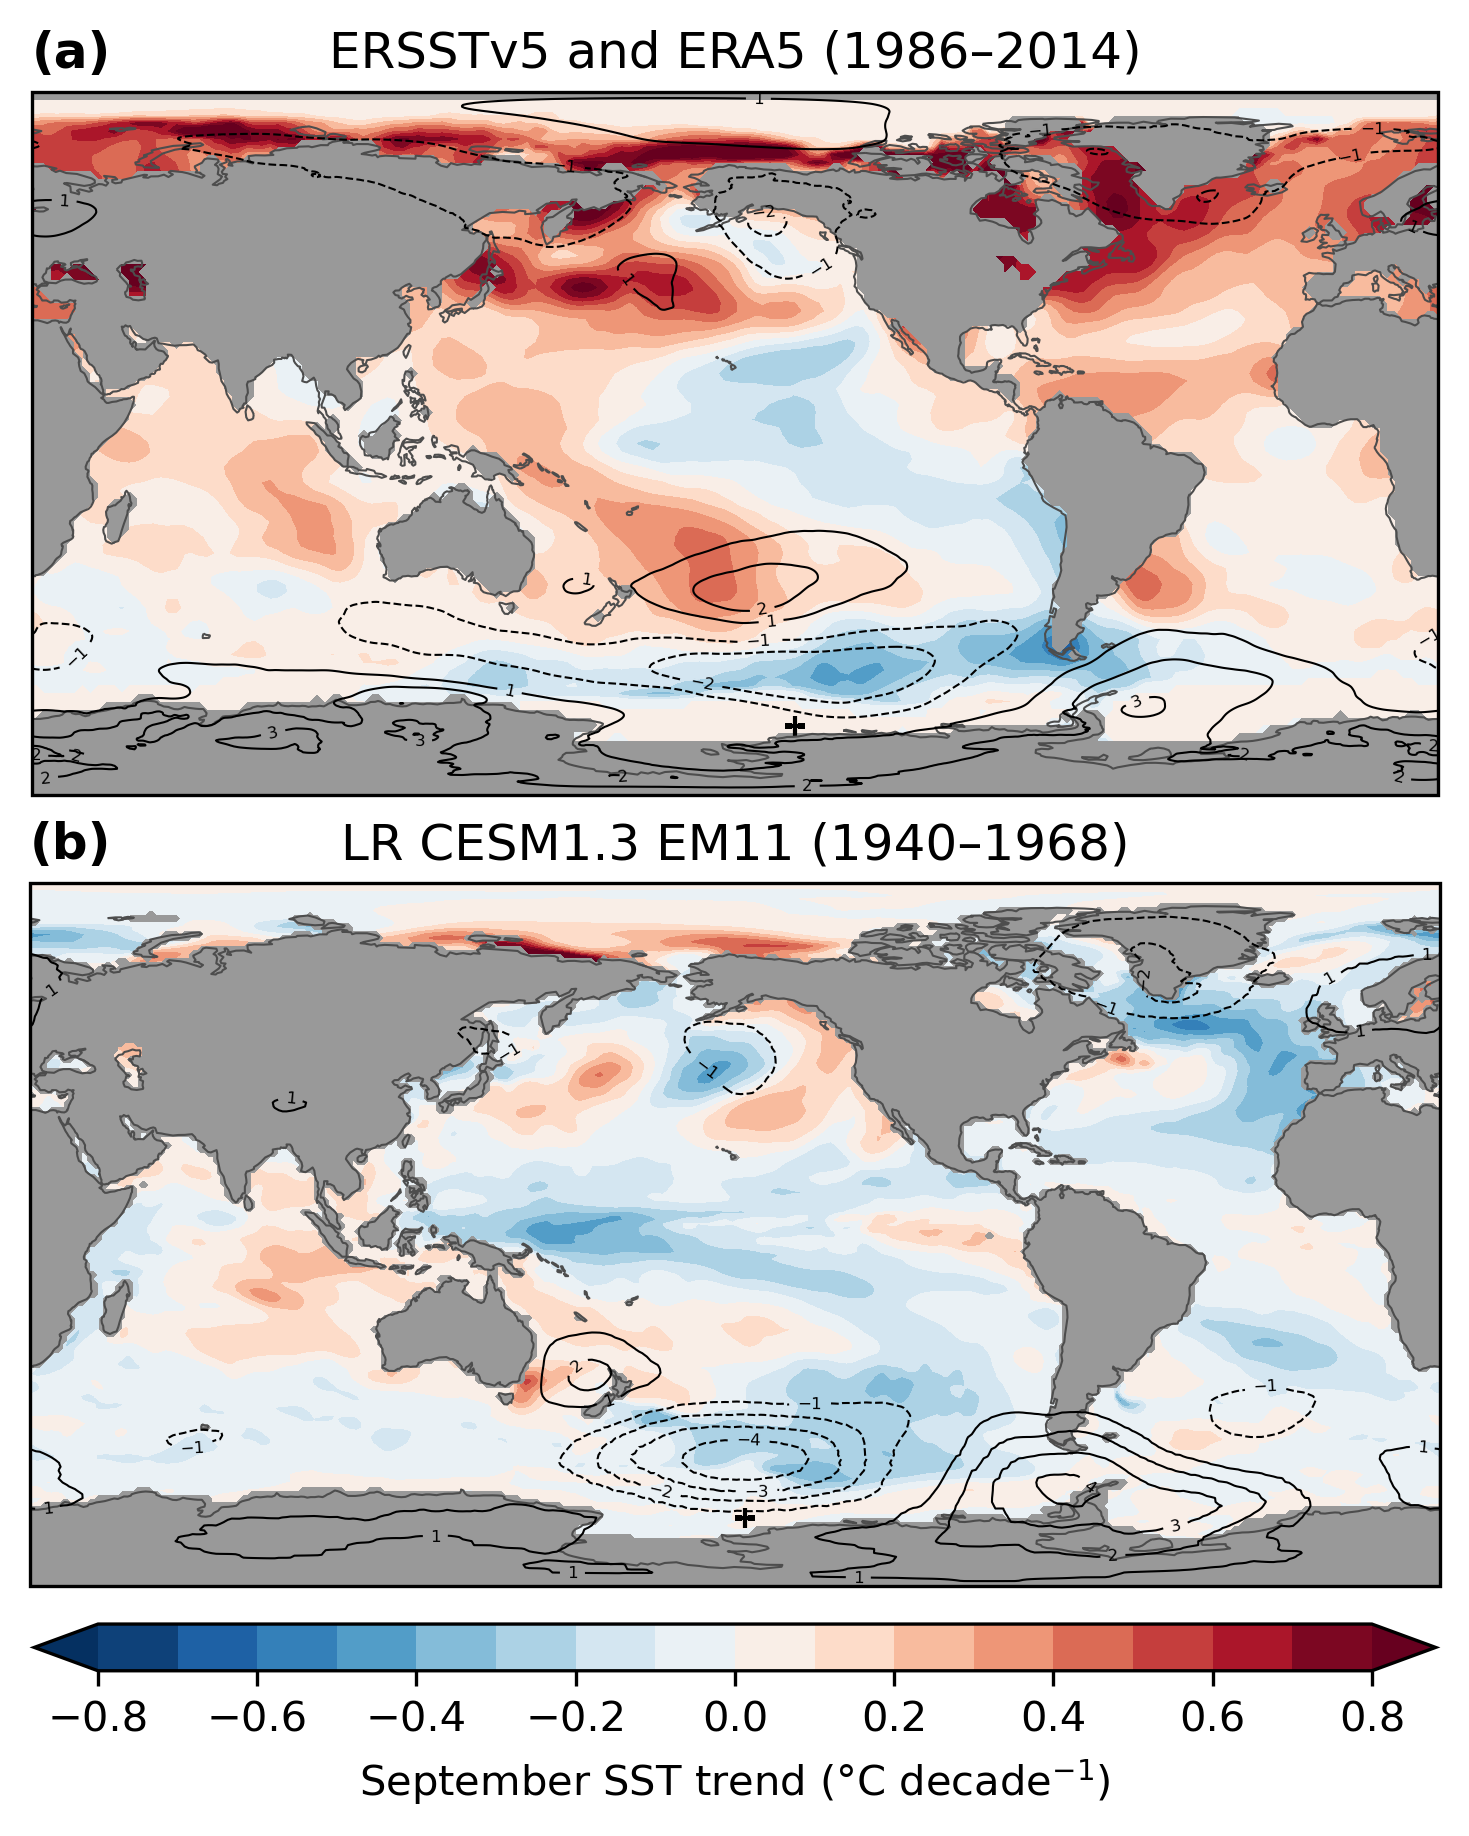

In [41]:
fig = plt.figure(dpi=300, layout='constrained', figsize=(5, 6))
ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree(central_longitude=205))
ax2 = fig.add_subplot(212, projection=ccrs.PlateCarree(central_longitude=205))

cf1 = ax1.contourf(ersst_lon_cyc, ersst_sep_trend.lat, ersst_sep_trend_cyc, levels=np.arange(-.8, .81, 0.1), extend='both', cmap='RdBu_r', transform=ccrs.PlateCarree())
cs1 = ax1.contour(era_lon_cyc, era5slp_sep_trend.latitude, 0.01*era5slp_sep_trend_cyc, levels=[-4, -3, -2, -1, 1, 2, 3, 4], colors='k', linewidths=0.5, transform=ccrs.PlateCarree())
ax1.scatter(era5_asl_sep_mean.longitude, era5_asl_sep_mean.latitude, marker='+', color='k', s=25, linewidths=1, transform=ccrs.PlateCarree())

cf2 = ax2.contourf(lr_lon_cyc, lr_sst_ds.lat.isel(ens_member=0, time=0), lr_sst_sep_trend_cyc, levels=np.arange(-.8, .81, 0.1), extend='both', cmap='RdBu_r', transform=ccrs.PlateCarree())
cs2 = ax2.contour(lr_lon_cyc, lr_slp_sep_trend.lat, 0.01*lr_slp_sep_trend_cyc, levels=[-4, -3, -2, -1, 1, 2, 3, 4], colors='k', linewidths=0.5, transform=ccrs.PlateCarree())
ax2.scatter(lr_asl_sep_mean.lon, lr_asl_sep_mean.lat, marker='+', color='k', s=25, linewidths=1, transform=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    ax.set_facecolor('0.6')
    ax.coastlines(linewidth=0.5, color='0.3')

# cax = fig.add_axes([0.86, 0.25, 0.02, 0.5])

plt.colorbar(cf2, orientation='horizontal', label='September SST trend (°C decade$^{-1}$)', shrink=.95, aspect=30)
# plt.colorbar(cf2)
plt.clabel(cs1, fontsize=4)
plt.clabel(cs2, fontsize=4)

ax1.set_title('(a)', fontweight='bold', loc='left')
ax1.set_title('ERSSTv5 and ERA5 (1986–2014)')
ax2.set_title('(b)', fontweight='bold', loc='left')
ax2.set_title('LR CESM1.3 EM11 (1940–1968)')

Text(0.5, 1.0, 'LR CESM1.3 EM11 (1940–1968)')

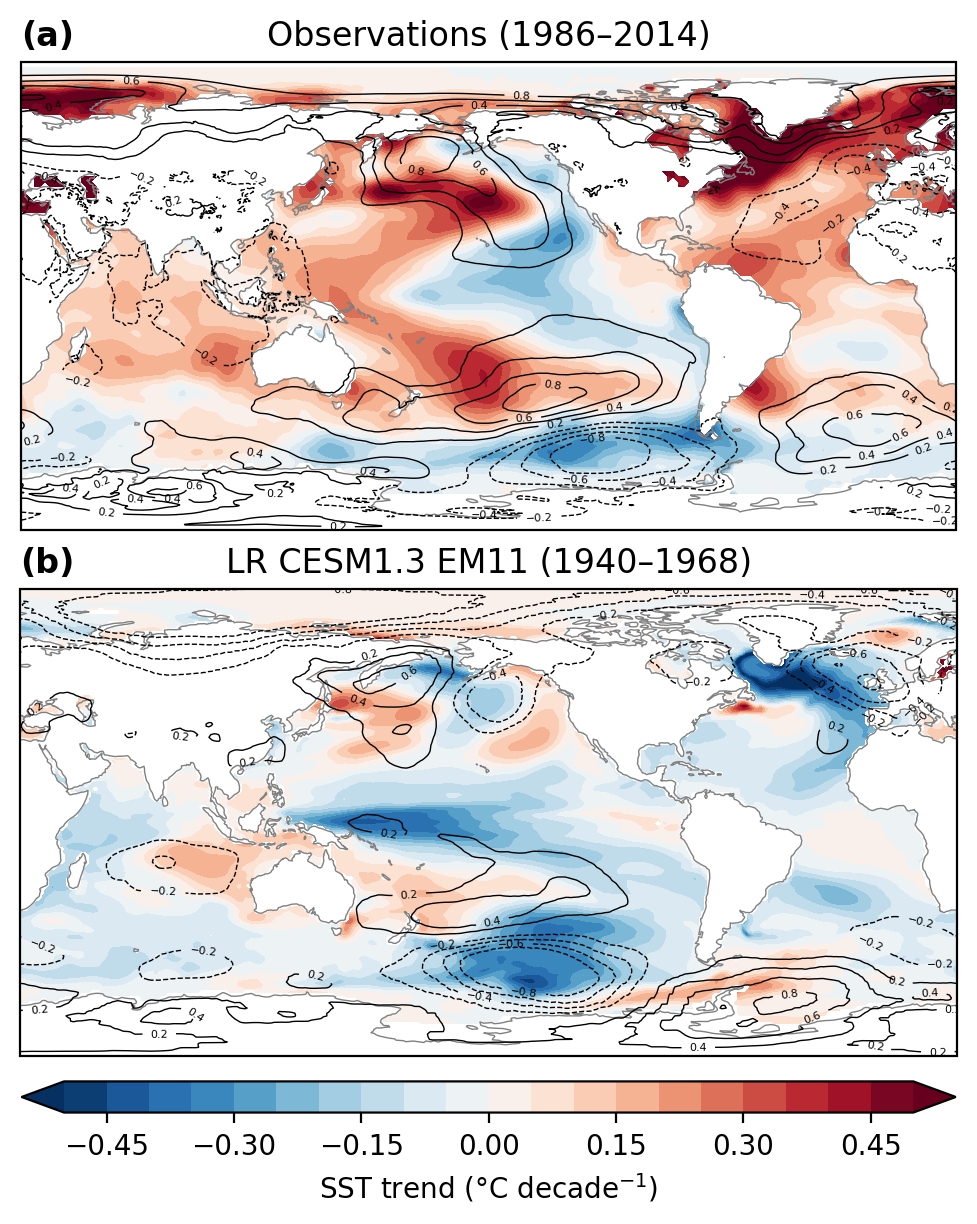

In [42]:
fig = plt.figure(dpi=200, layout='constrained', figsize=(5, 6))
ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree(central_longitude=205))
ax2 = fig.add_subplot(212, projection=ccrs.PlateCarree(central_longitude=205))

cf1 = ax1.contourf(ersst_lon_cyc, ersst_trend.lat, ersst_trend_cyc, levels=np.arange(-0.5, 0.51, 0.05), extend='both', cmap='RdBu_r', transform=ccrs.PlateCarree())
cs1 = ax1.contour(era_lon_cyc, era5slp_trend.latitude, 0.01*era5slp_trend_cyc, levels=0.2*np.array([-4, -3, -2, -1, 1, 2, 3, 4]), colors='k', linewidths=0.5, transform=ccrs.PlateCarree())

cf2 = ax2.contourf(lr_lon_cyc, lr_sst_ds.lat.isel(ens_member=0, time=0), lr_sst_trend_cyc, levels=np.arange(-0.5, 0.51, 0.05), extend='both', cmap='RdBu_r', transform=ccrs.PlateCarree())
cs2 = ax2.contour(lr_lon_cyc, lr_slp_trend.lat, 0.01*lr_slp_trend_cyc, levels=0.2*np.array([-4, -3, -2, -1, 1, 2, 3, 4]), colors='k', linewidths=0.5, transform=ccrs.PlateCarree())

for ax in [ax1, ax2]:
    ax.coastlines(linewidth=0.5, color='0.5')

# cax = fig.add_axes([0.86, 0.25, 0.02, 0.5])

plt.colorbar(cf2, orientation='horizontal', label='SST trend (°C decade$^{-1}$)', shrink=.95, aspect=30)
# plt.colorbar(cf2)
plt.clabel(cs1, fontsize=4)
plt.clabel(cs2, fontsize=4)

ax1.set_title('(a)', fontweight='bold', loc='left')
ax1.set_title('Observations (1986–2014)')
ax2.set_title('(b)', fontweight='bold', loc='left')
ax2.set_title('LR CESM1.3 EM11 (1940–1968)')

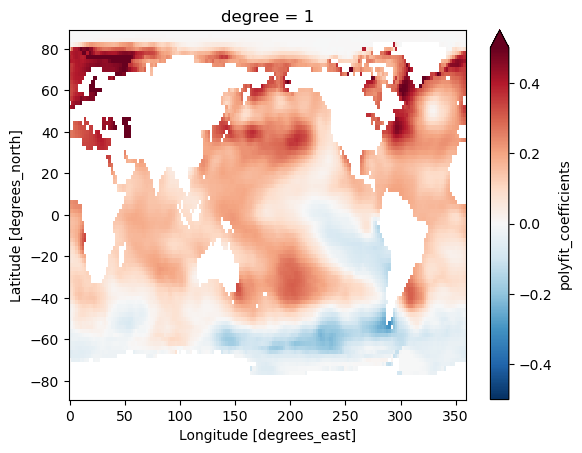

In [43]:
(ns_per_dec*((ersst_anom.sel(time=slice('1979', '2020'))).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients)).plot(vmin=-.5, vmax=.5, cmap='RdBu_r')

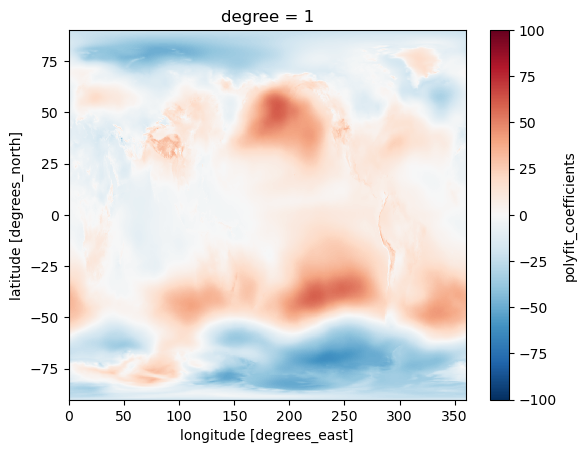

In [44]:
(ns_per_dec*((era5slp_anom.sel(time=slice('1979', '2020'))).polyfit('time', deg=1).sel(degree=1).polyfit_coefficients)).plot(vmin=-100, vmax=100, cmap='RdBu_r')